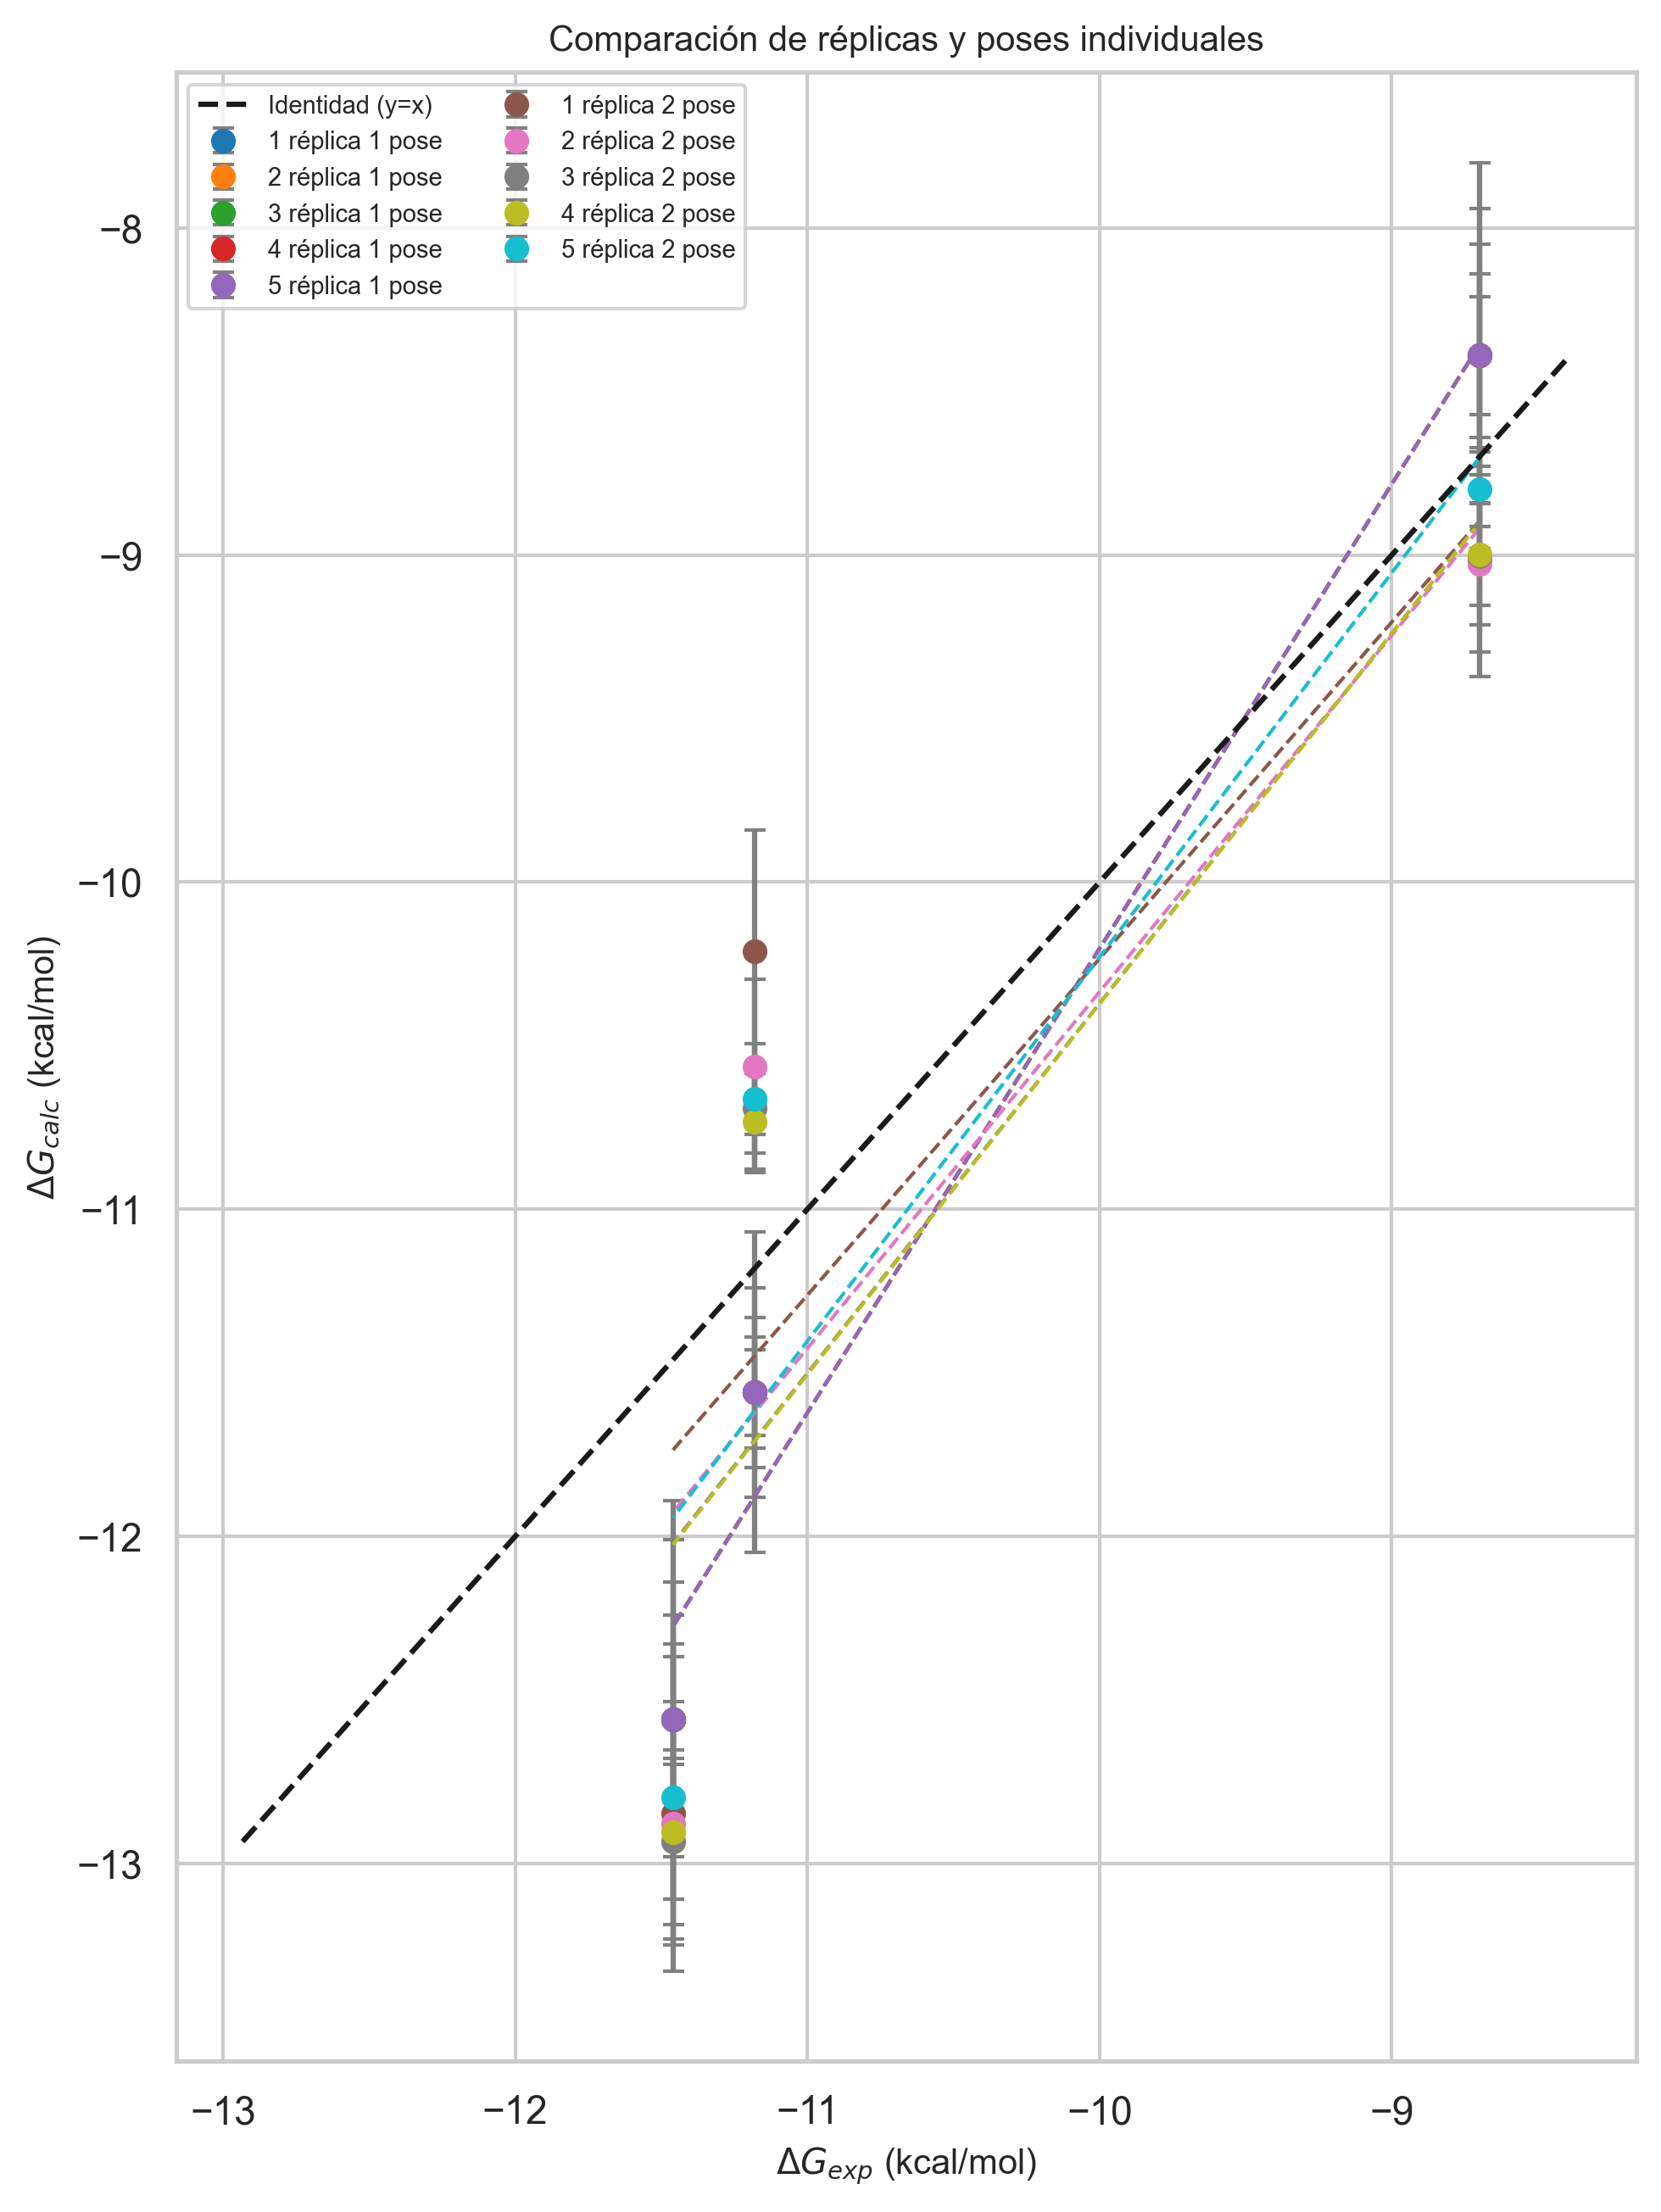

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

# Lista con los nombres de tus archivos Excel para réplicas y poses individuales
archivos_replicas = [
    ("1P1R.xlsx", "1 réplica 1 pose"),
    ("1P2R.xlsx", "2 réplica 1 pose"),
    ("1P3R.xlsx", "3 réplica 1 pose"),
    ("1P4R.xlsx", "4 réplica 1 pose"),
    ("1P5R.xlsx", "5 réplica 1 pose"),
    ("2P1R.xlsx", "1 réplica 2 pose"),
    ("2P2R.xlsx", "2 réplica 2 pose"),
    ("2P3R.xlsx", "3 réplica 2 pose"),
    ("2P4R.xlsx", "4 réplica 2 pose"),
    ("2P5R.xlsx", "5 réplica 2 pose"),
]

colores = sns.color_palette("tab10", n_colors=10)

for idx, (archivo, etiqueta) in enumerate(archivos_replicas):
    df = pd.read_excel(archivo)
    # Asegúrate que tus archivos tengan estas columnas:
    # 'DG_exp' para valor experimental,
    # 'DG_calc' para valor calculado,
    # 'std_dev' para desviación estándar/error.
    X = df['DG_exp'].values
    y = df['DG_calc'].values
    yerr = df['std_dev'].values

    # Ajuste de regresión lineal
    model = LinearRegression()
    model.fit(X.reshape(-1,1), y)
    y_pred = model.predict(X.reshape(-1,1))

    color = colores[idx % 10]  # ciclo de colores

    # Graficar puntos con barras de error
    plt.errorbar(X, y, yerr=yerr, fmt='o', color=color,
                 ecolor='gray', capsize=3,
                 label=etiqueta)
    # Graficar línea de regresión
    plt.plot(X, y_pred, color=color, linestyle='--', linewidth=1)

# Línea identidad (y=x) para referencia visual
all_vals = []
for archivo, _ in archivos_replicas:
    df = pd.read_excel(archivo)
    all_vals.extend(df['DG_exp'].values)
    all_vals.extend(df['DG_calc'].values)
min_val = min(all_vals)
max_val = max(all_vals)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Identidad (y=x)')

plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Comparación de réplicas y poses individuales', fontsize=10)
plt.legend(fontsize=7, loc='best', ncol=2)
plt.tight_layout()
plt.savefig('comparacion_replicas_poses_individuales.png', dpi=300)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_reg

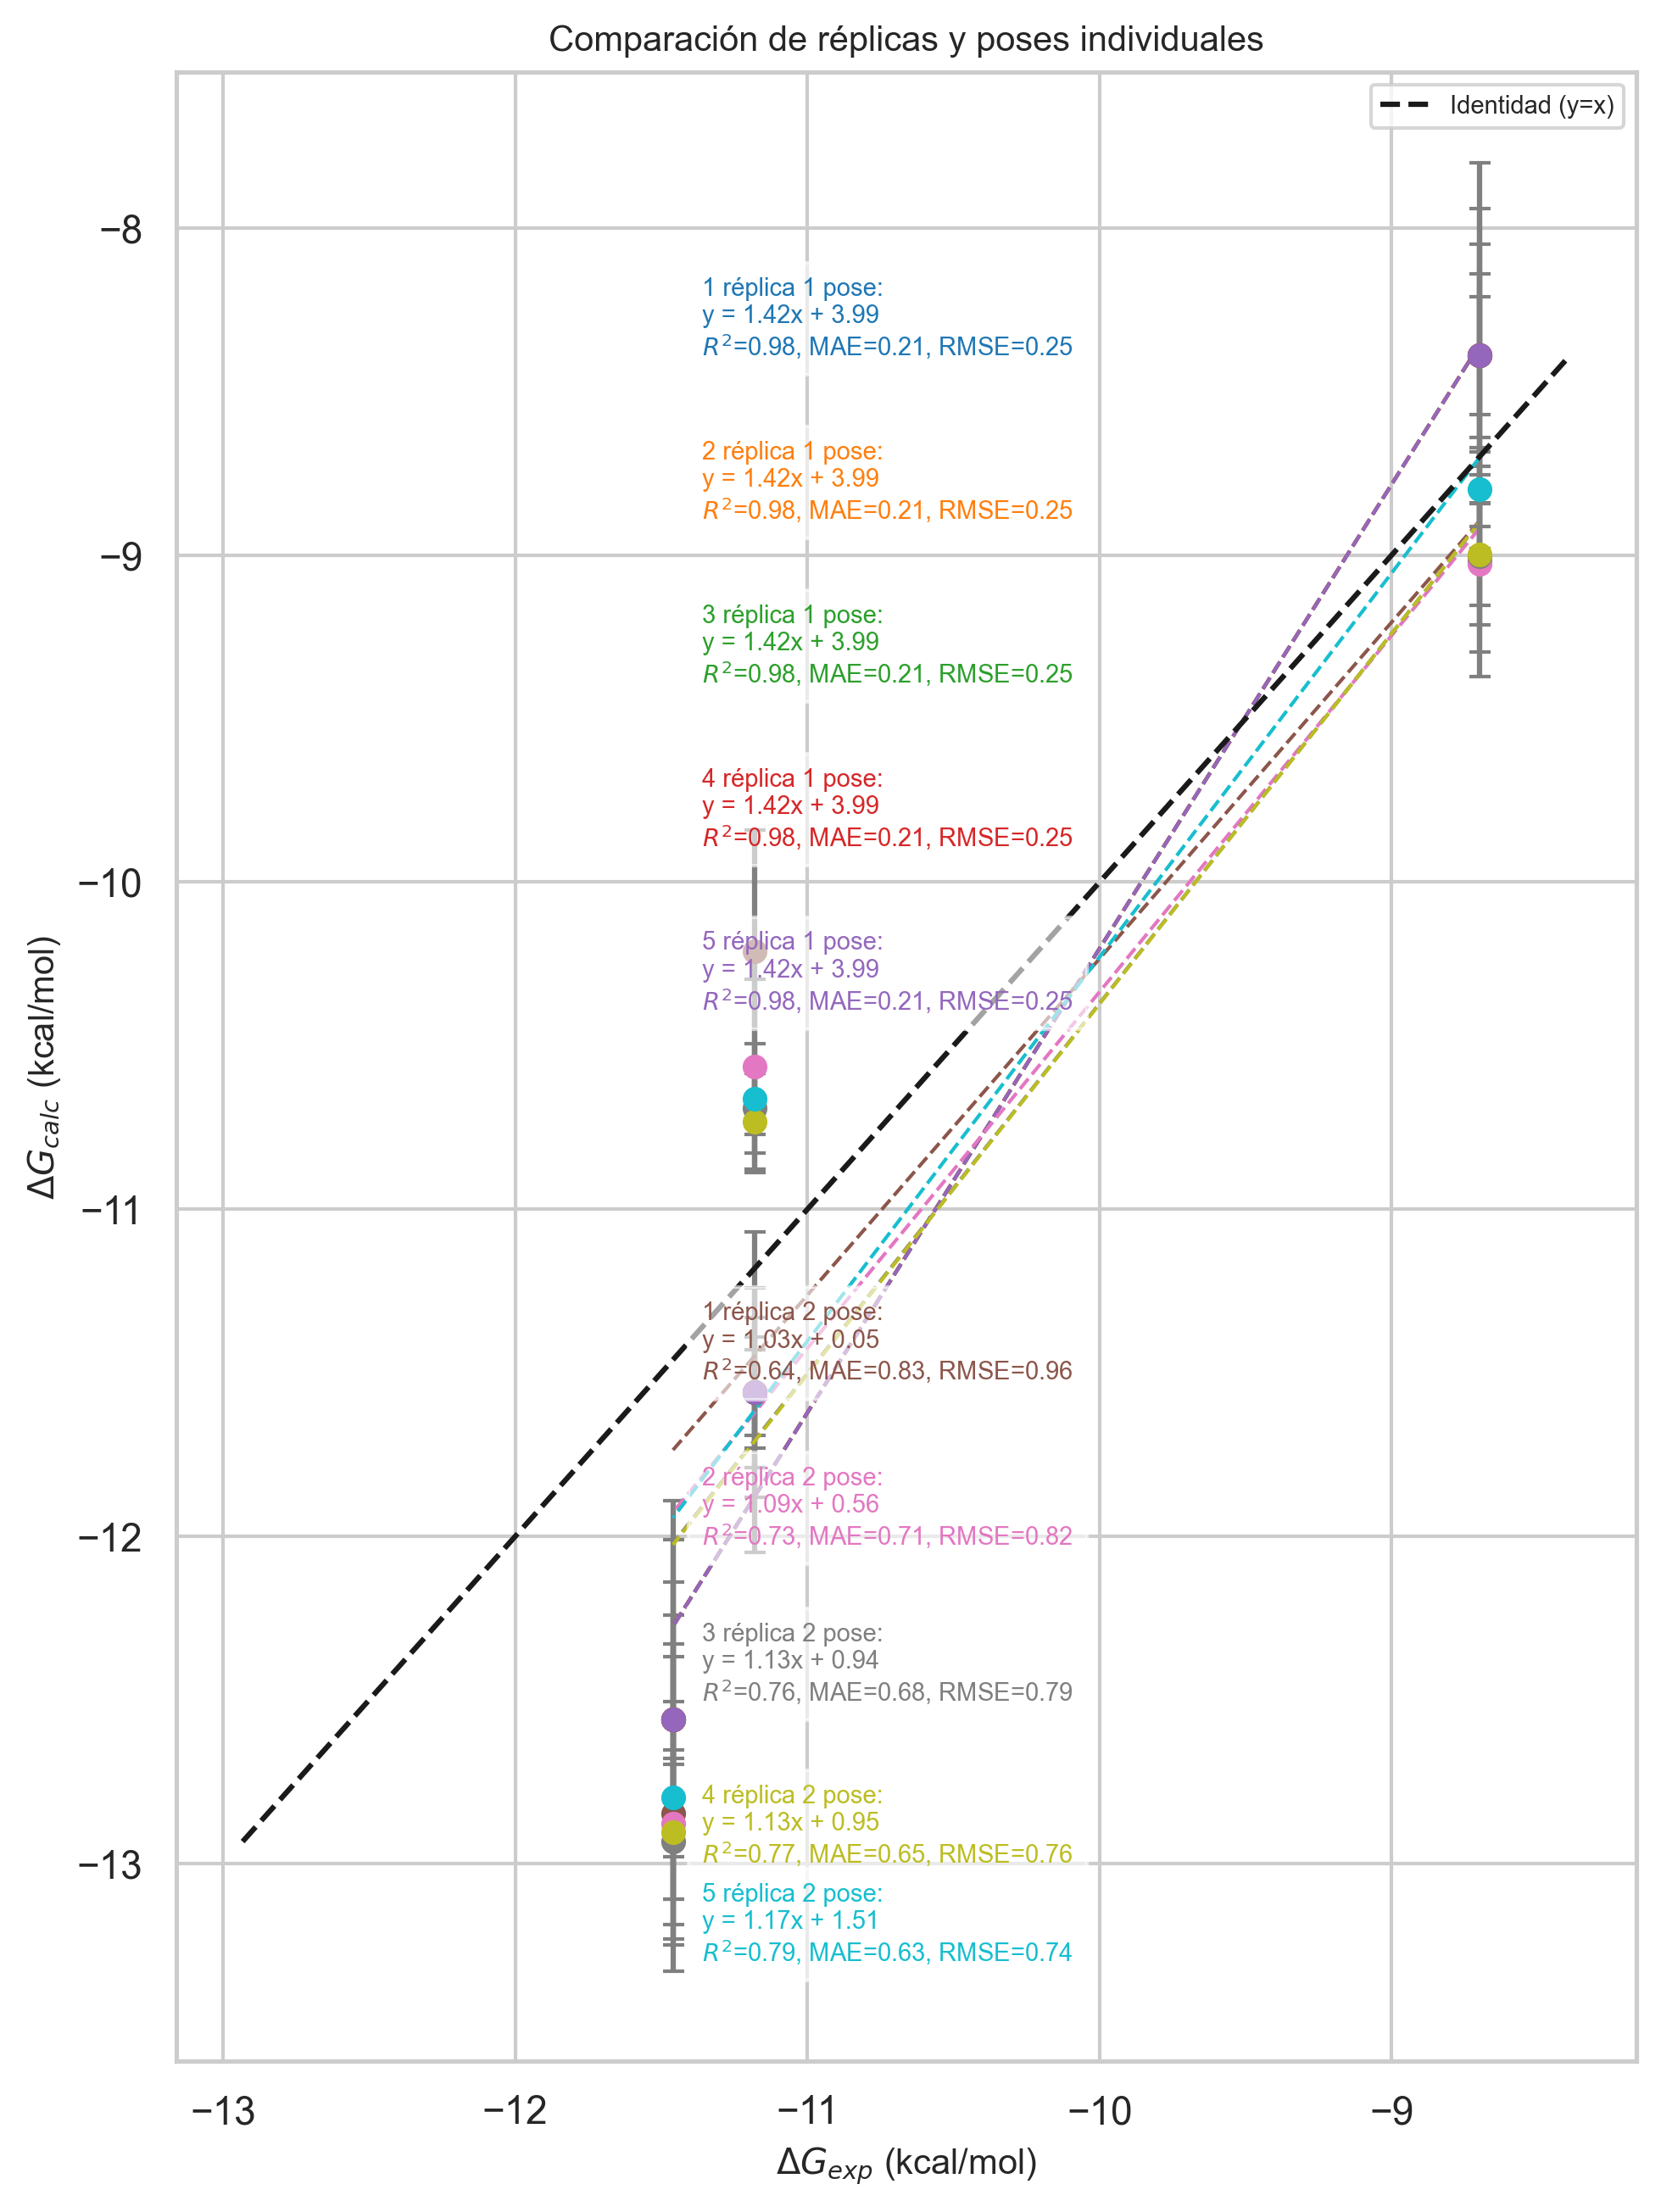

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

# Lista con los nombres de tus archivos Excel para réplicas y poses individuales
archivos_replicas = [
    ("1P1R.xlsx", "1 réplica 1 pose"),
    ("1P2R.xlsx", "2 réplica 1 pose"),
    ("1P3R.xlsx", "3 réplica 1 pose"),
    ("1P4R.xlsx", "4 réplica 1 pose"),
    ("1P5R.xlsx", "5 réplica 1 pose"),
    ("2P1R.xlsx", "1 réplica 2 pose"),
    ("2P2R.xlsx", "2 réplica 2 pose"),
    ("2P3R.xlsx", "3 réplica 2 pose"),
    ("2P4R.xlsx", "4 réplica 2 pose"),
    ("2P5R.xlsx", "5 réplica 2 pose"),
]

colores = sns.color_palette("tab10", n_colors=10)

for idx, (archivo, etiqueta) in enumerate(archivos_replicas):
    df = pd.read_excel(archivo)
    # Asegúrate que tus archivos tengan estas columnas:
    # 'DG_exp' para valor experimental,
    # 'DG_calc' para valor calculado,
    # 'std_dev' para desviación estándar/error.
    X = df['DG_exp'].values.reshape(-1,1)
    y = df['DG_calc'].values
    yerr = df['std_dev'].values

    # Ajuste de regresión lineal
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Cálculo de métricas
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred, squared=False)
    slope = model.coef_[0]
    intercept = model.intercept_

    color = colores[idx % 10]  # ciclo de colores

    # Graficar puntos con barras de error
    plt.errorbar(X.flatten(), y, yerr=yerr, fmt='o', color=color,
                 ecolor='gray', capsize=3)
    # Graficar línea de regresión
    plt.plot(X.flatten(), y_pred, color=color, linestyle='--', linewidth=1)

    # Añadir texto con la ecuación y métricas, ajustando la posición para no sobreponer
    xpos = np.min(X) + 0.1
    ypos = np.max(y) - (idx * 0.5)  # baja un poco cada texto para no amontonar
    texto = (f"{etiqueta}:\n"
             f"y = {slope:.2f}x + {intercept:.2f}\n"
             f"$R^2$={r2:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}")
    plt.text(xpos, ypos, texto, fontsize=7, color=color, bbox=dict(facecolor='white', alpha=0.6))

# Línea identidad (y=x) para referencia visual
all_vals = []
for archivo, _ in archivos_replicas:
    df = pd.read_excel(archivo)
    all_vals.extend(df['DG_exp'].values)
    all_vals.extend(df['DG_calc'].values)
min_val = min(all_vals)
max_val = max(all_vals)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Identidad (y=x)')

plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Comparación de réplicas y poses individuales', fontsize=10)
plt.legend(fontsize=7, loc='best', ncol=2)
plt.tight_layout()
plt.savefig('comparacion_replicas_poses_individuales_con_metrica.png', dpi=300)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_reg

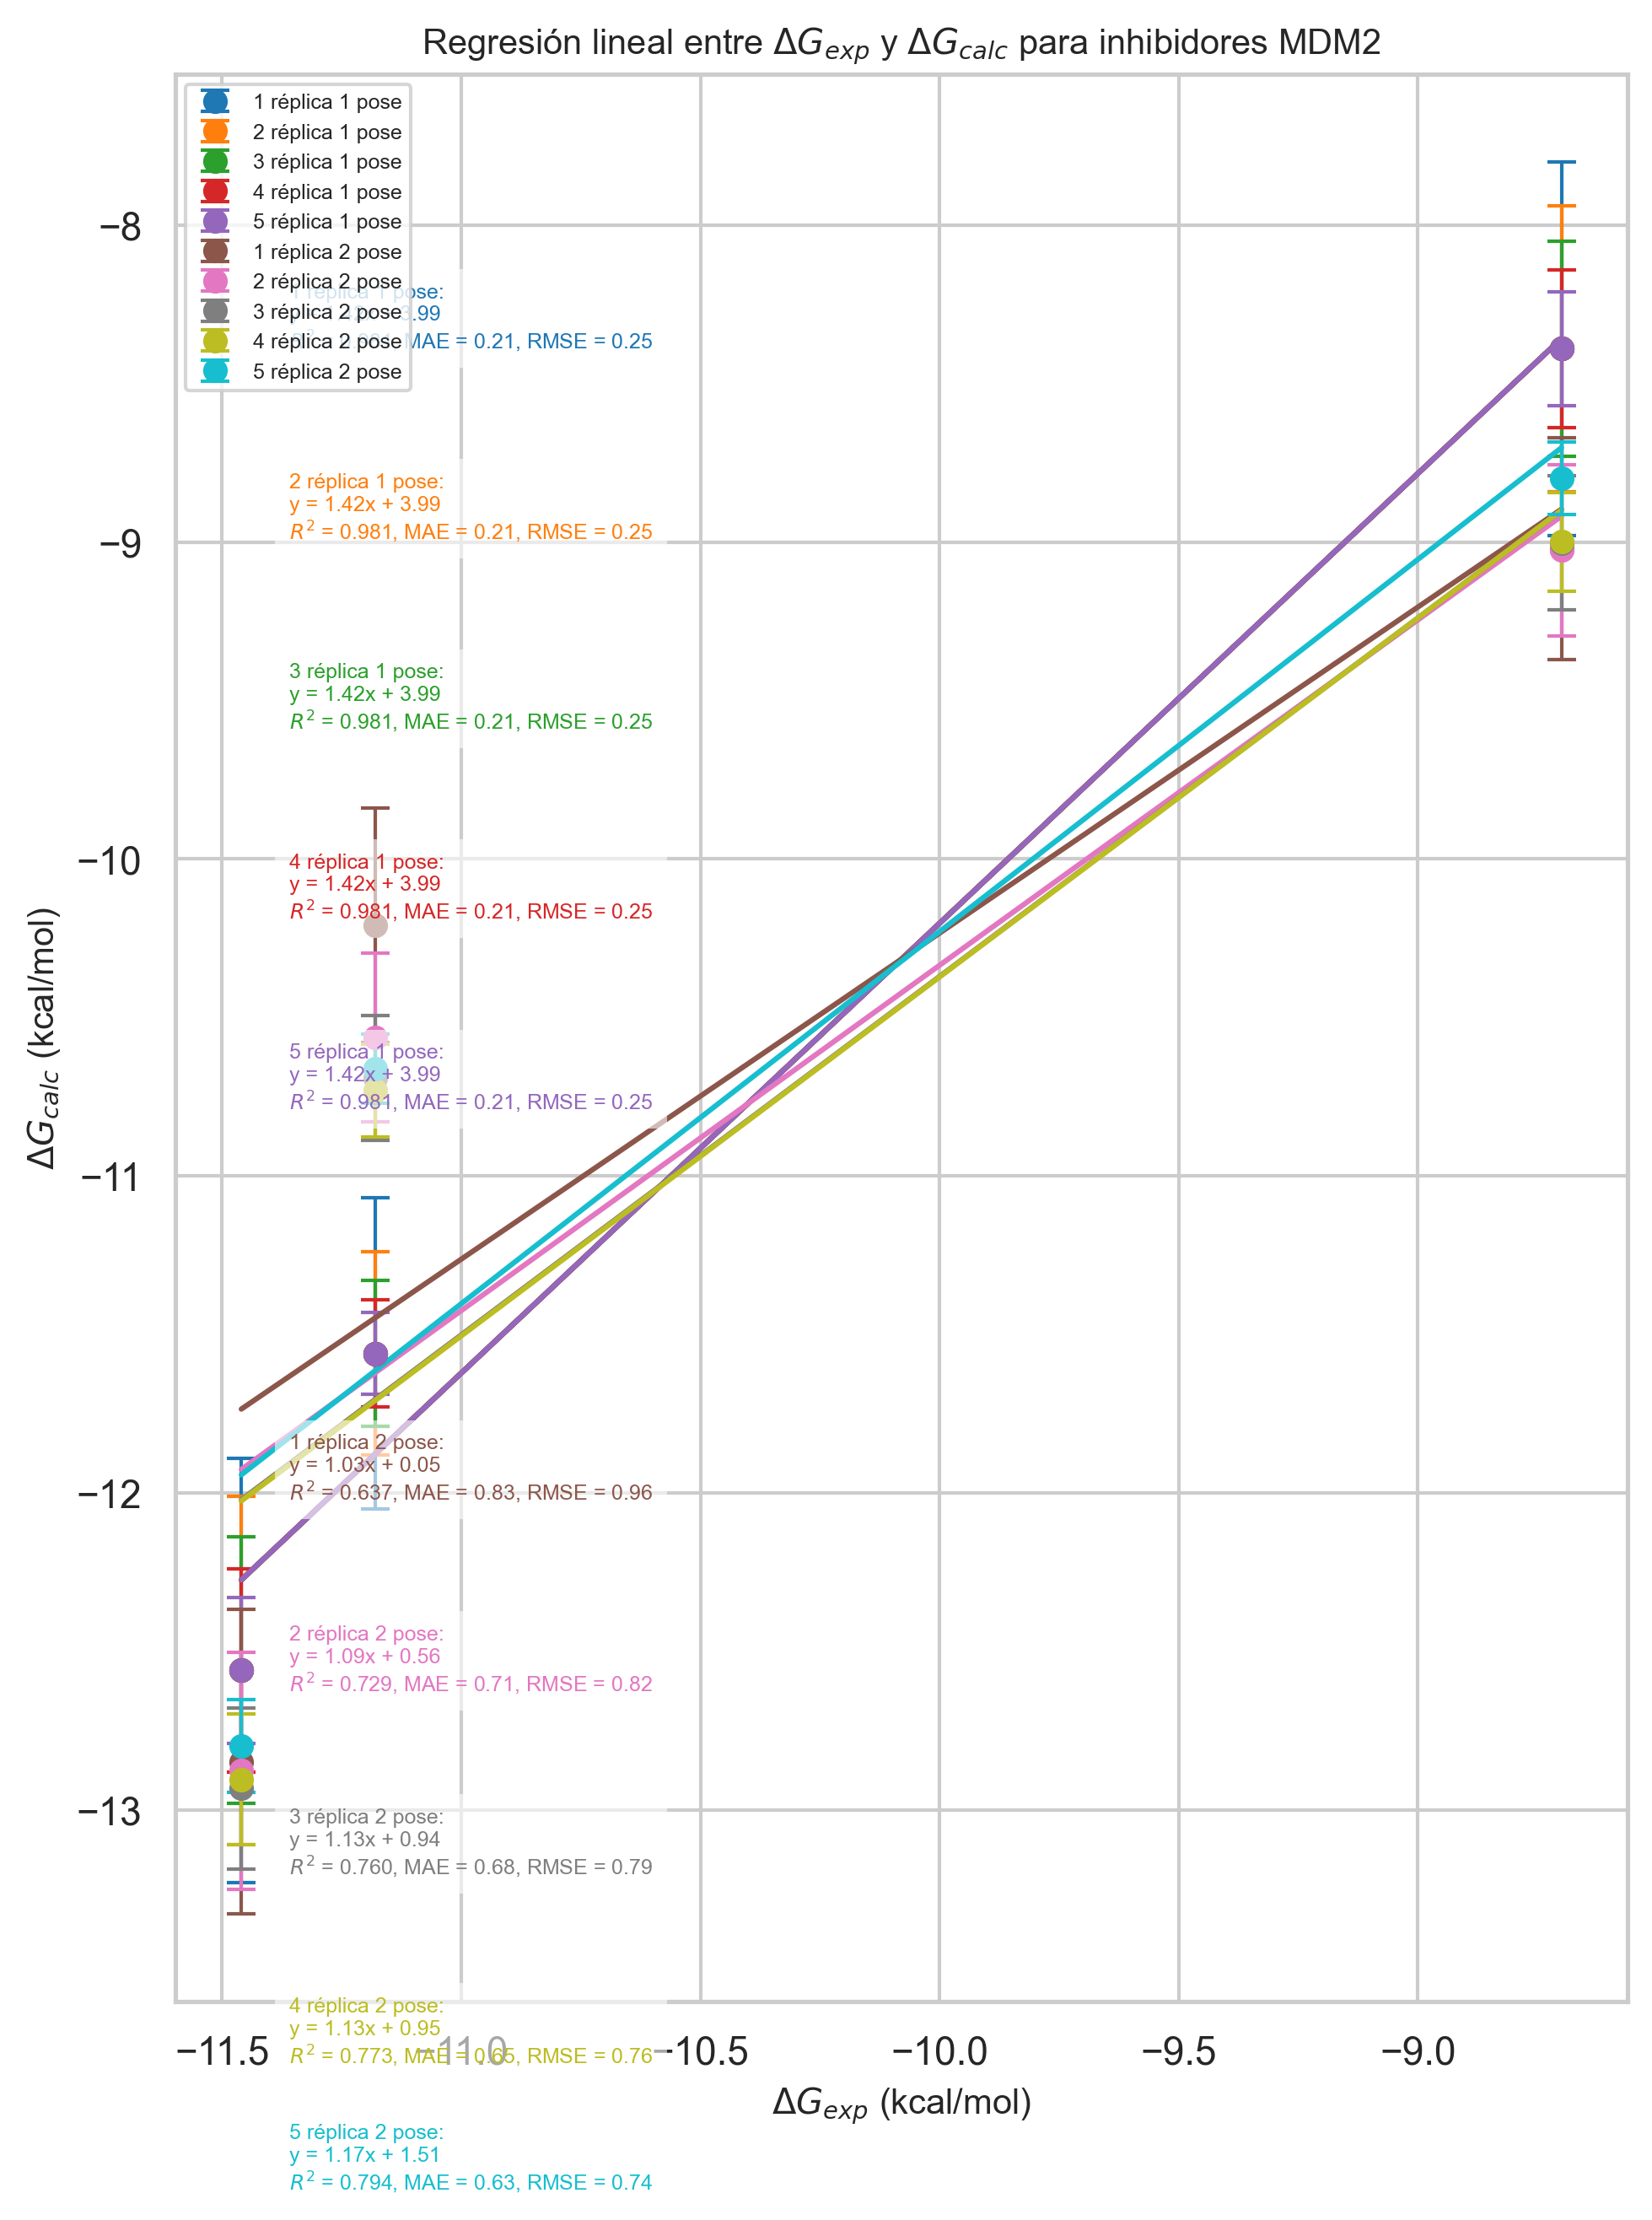

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

sns.set(style="whitegrid")

# Lista con los nombres de tus archivos Excel y leyendas
archivos_replicas = [
    ("1P1R.xlsx", "1 réplica 1 pose"),
    ("1P2R.xlsx", "2 réplica 1 pose"),
    ("1P3R.xlsx", "3 réplica 1 pose"),
    ("1P4R.xlsx", "4 réplica 1 pose"),
    ("1P5R.xlsx", "5 réplica 1 pose"),
    ("2P1R.xlsx", "1 réplica 2 pose"),
    ("2P2R.xlsx", "2 réplica 2 pose"),
    ("2P3R.xlsx", "3 réplica 2 pose"),
    ("2P4R.xlsx", "4 réplica 2 pose"),
    ("2P5R.xlsx", "5 réplica 2 pose"),
]

# Supongo que el experimental es el mismo para todos y está en una variable o archivo
# Aquí lo pongo como ejemplo:
DG_exp = np.array([-8.7, -11.18, -11.46])  # Cambia por tus datos experimentales reales

plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

colores = plt.cm.tab10.colors  # 10 colores para líneas diferentes

for i, (archivo, leyenda) in enumerate(archivos_replicas):
    # Leer datos del excel
    df = pd.read_excel(archivo)

    # Asumo que en cada archivo tienes columnas llamadas 'DG_calc' y 'std_dev' y que DG_exp está fijo
    DG_calc = df['DG_calc'].values
    std_dev = df['std_dev'].values

    # Ajuste lineal con sklearn
    model = LinearRegression()
    X = DG_exp.reshape(-1, 1)
    y = DG_calc
    model.fit(X, y)
    y_pred = model.predict(X)

    # Métricas
    slope = model.coef_[0]
    intercept = model.intercept_
    r_squared = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred, squared=False)

    color = colores[i % len(colores)]

    # Puntos con barras de error (sin líneas negras que unan puntos)
    plt.errorbar(DG_exp, DG_calc, yerr=std_dev, fmt='o', color=color,
                 ecolor=color, elinewidth=1, capsize=4, linestyle='none', label=leyenda)

    # Línea de regresión
    plt.plot(DG_exp, y_pred, color=color, linewidth=1.5)

    # Anotación con ecuación y métricas (puedes ajustar coordenadas para evitar sobreposiciones)
    plt.text(min(DG_exp)+0.1, max(DG_calc) - i*0.6, 
             f'{leyenda}:\n' +
             f'y = {slope:.2f}x + {intercept:.2f}\n' +
             f'$R^2$ = {r_squared:.3f}, MAE = {mae:.2f}, RMSE = {rmse:.2f}',
             fontsize=6, color=color, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Etiquetas y título
plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Regresión lineal entre $\Delta G_{exp}$ y $\Delta G_{calc}$ para inhibidores MDM2', fontsize=10)

# Leyenda en esquina superior izquierda
plt.legend(loc='upper left', fontsize=6)

plt.tight_layout()
plt.savefig('DG_regression_multiple_replicas_poses.png', dpi=300)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_reg

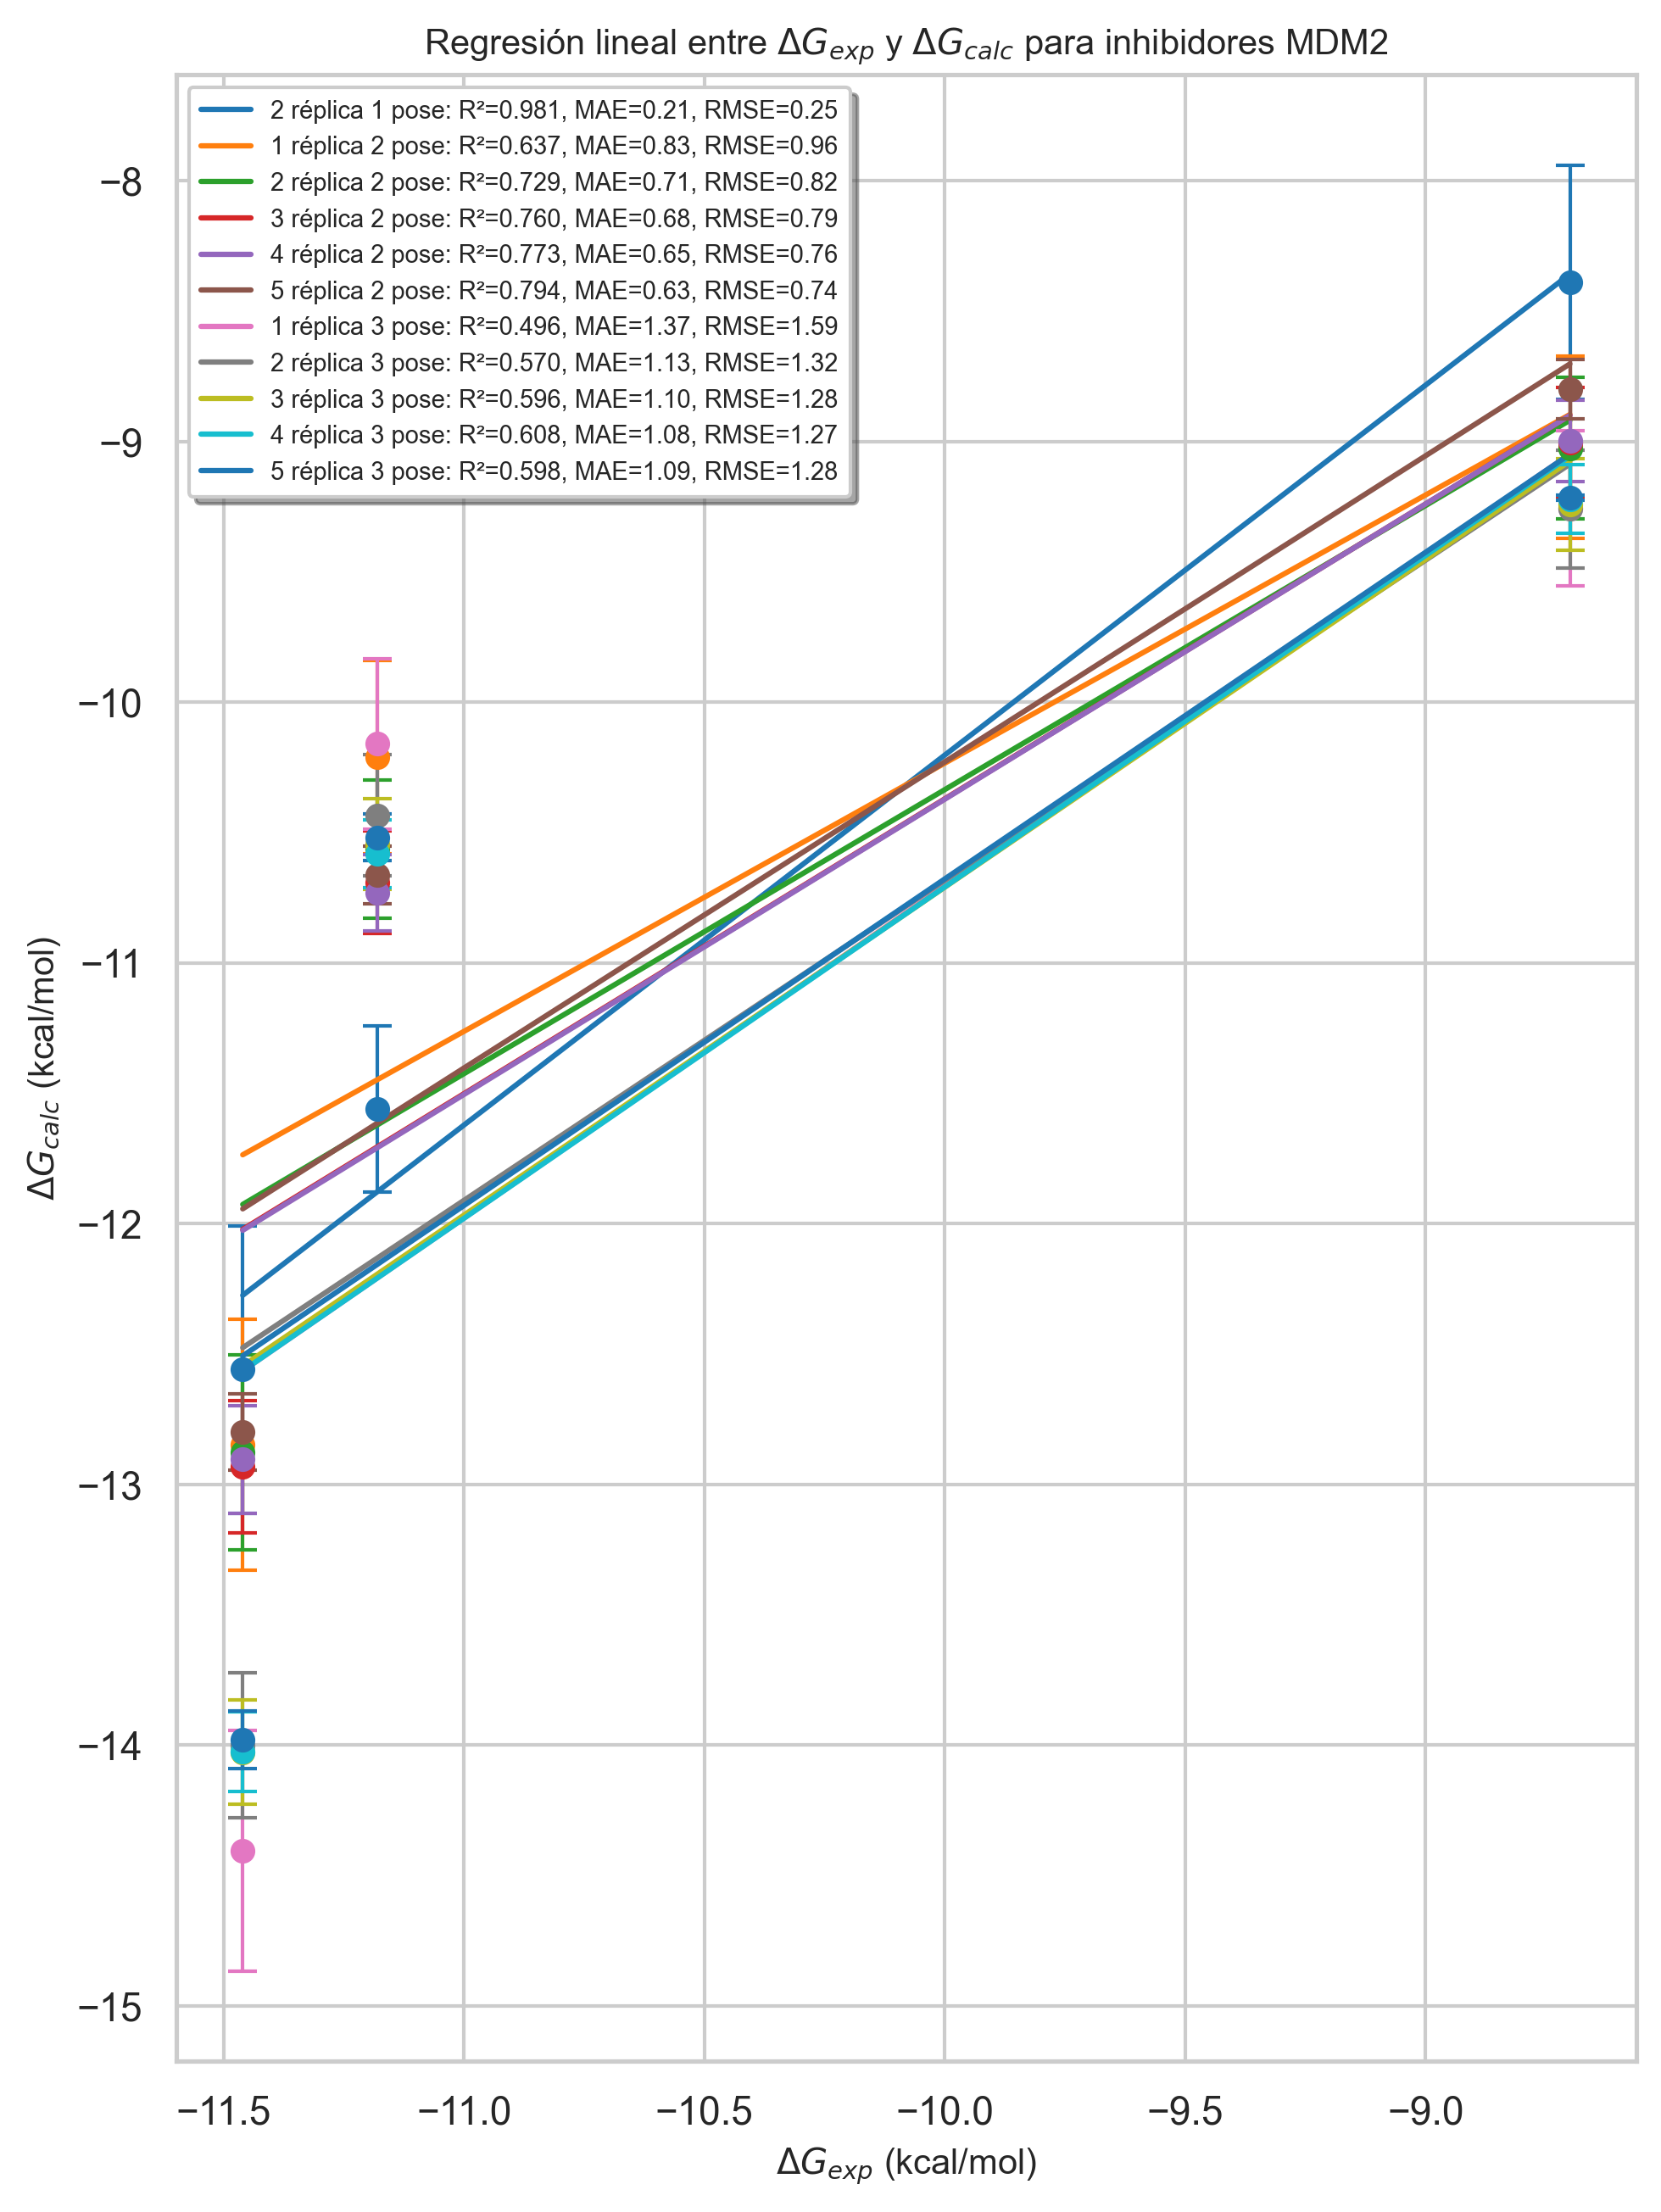

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

sns.set(style="whitegrid")

archivos_replicas = [
    #("1P1R.xlsx", "1 réplica 1 pose"),
    ("1P2R.xlsx", "2 réplica 1 pose"),
    #("1P3R.xlsx", "3 réplica 1 pose"),
    #("1P4R.xlsx", "4 réplica 1 pose"),
    #("1P5R.xlsx", "5 réplica 1 pose"),
    ("2P1R.xlsx", "1 réplica 2 pose"),
    ("2P2R.xlsx", "2 réplica 2 pose"),
    ("2P3R.xlsx", "3 réplica 2 pose"),
    ("2P4R.xlsx", "4 réplica 2 pose"),
    ("2P5R.xlsx", "5 réplica 2 pose"),
    ("3P1R.xlsx", "1 réplica 3 pose"),
    ("3P2R.xlsx", "2 réplica 3 pose"),
    ("3P3R.xlsx", "3 réplica 3 pose"),
    ("3P4R.xlsx", "4 réplica 3 pose"),
    ("3P5R.xlsx", "5 réplica 3 pose"),
]

DG_exp = np.array([-8.7, -11.18, -11.46])  # Ajusta a tus datos experimentales

plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

colores = plt.cm.tab10.colors

handles = []
labels = []

for i, (archivo, leyenda_base) in enumerate(archivos_replicas):
    df = pd.read_excel(archivo)
    DG_calc = df['DG_calc'].values
    std_dev = df['std_dev'].values

    model = LinearRegression()
    X = DG_exp.reshape(-1, 1)
    y = DG_calc
    model.fit(X, y)
    y_pred = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_
    r_squared = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred, squared=False)

    color = colores[i % len(colores)]

    # Puntos con barras de error
    plt.errorbar(DG_exp, DG_calc, yerr=std_dev, fmt='o', color=color,
                 ecolor=color, elinewidth=1, capsize=4, linestyle='none')

    # Línea de regresión
    linea, = plt.plot(DG_exp, y_pred, color=color, linewidth=1.5)

    # Construir la etiqueta con métricas para la leyenda
    etiqueta = (f"{leyenda_base}: "
                f"R²={r_squared:.3f}, "
                f"MAE={mae:.2f}, "
                f"RMSE={rmse:.2f}")
    
    handles.append(linea)
    labels.append(etiqueta)

plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Regresión lineal entre $\Delta G_{exp}$ y $\Delta G_{calc}$ para inhibidores MDM2', fontsize=10)

# Leyenda compacta en esquina superior izquierda
plt.legend(handles, labels, loc='upper left', fontsize=7, frameon=True, fancybox=True, shadow=True, borderpad=0.5)

plt.tight_layout()
plt.savefig('DG_regression_con_metricas_en_leyenda.png', dpi=300)
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_reg

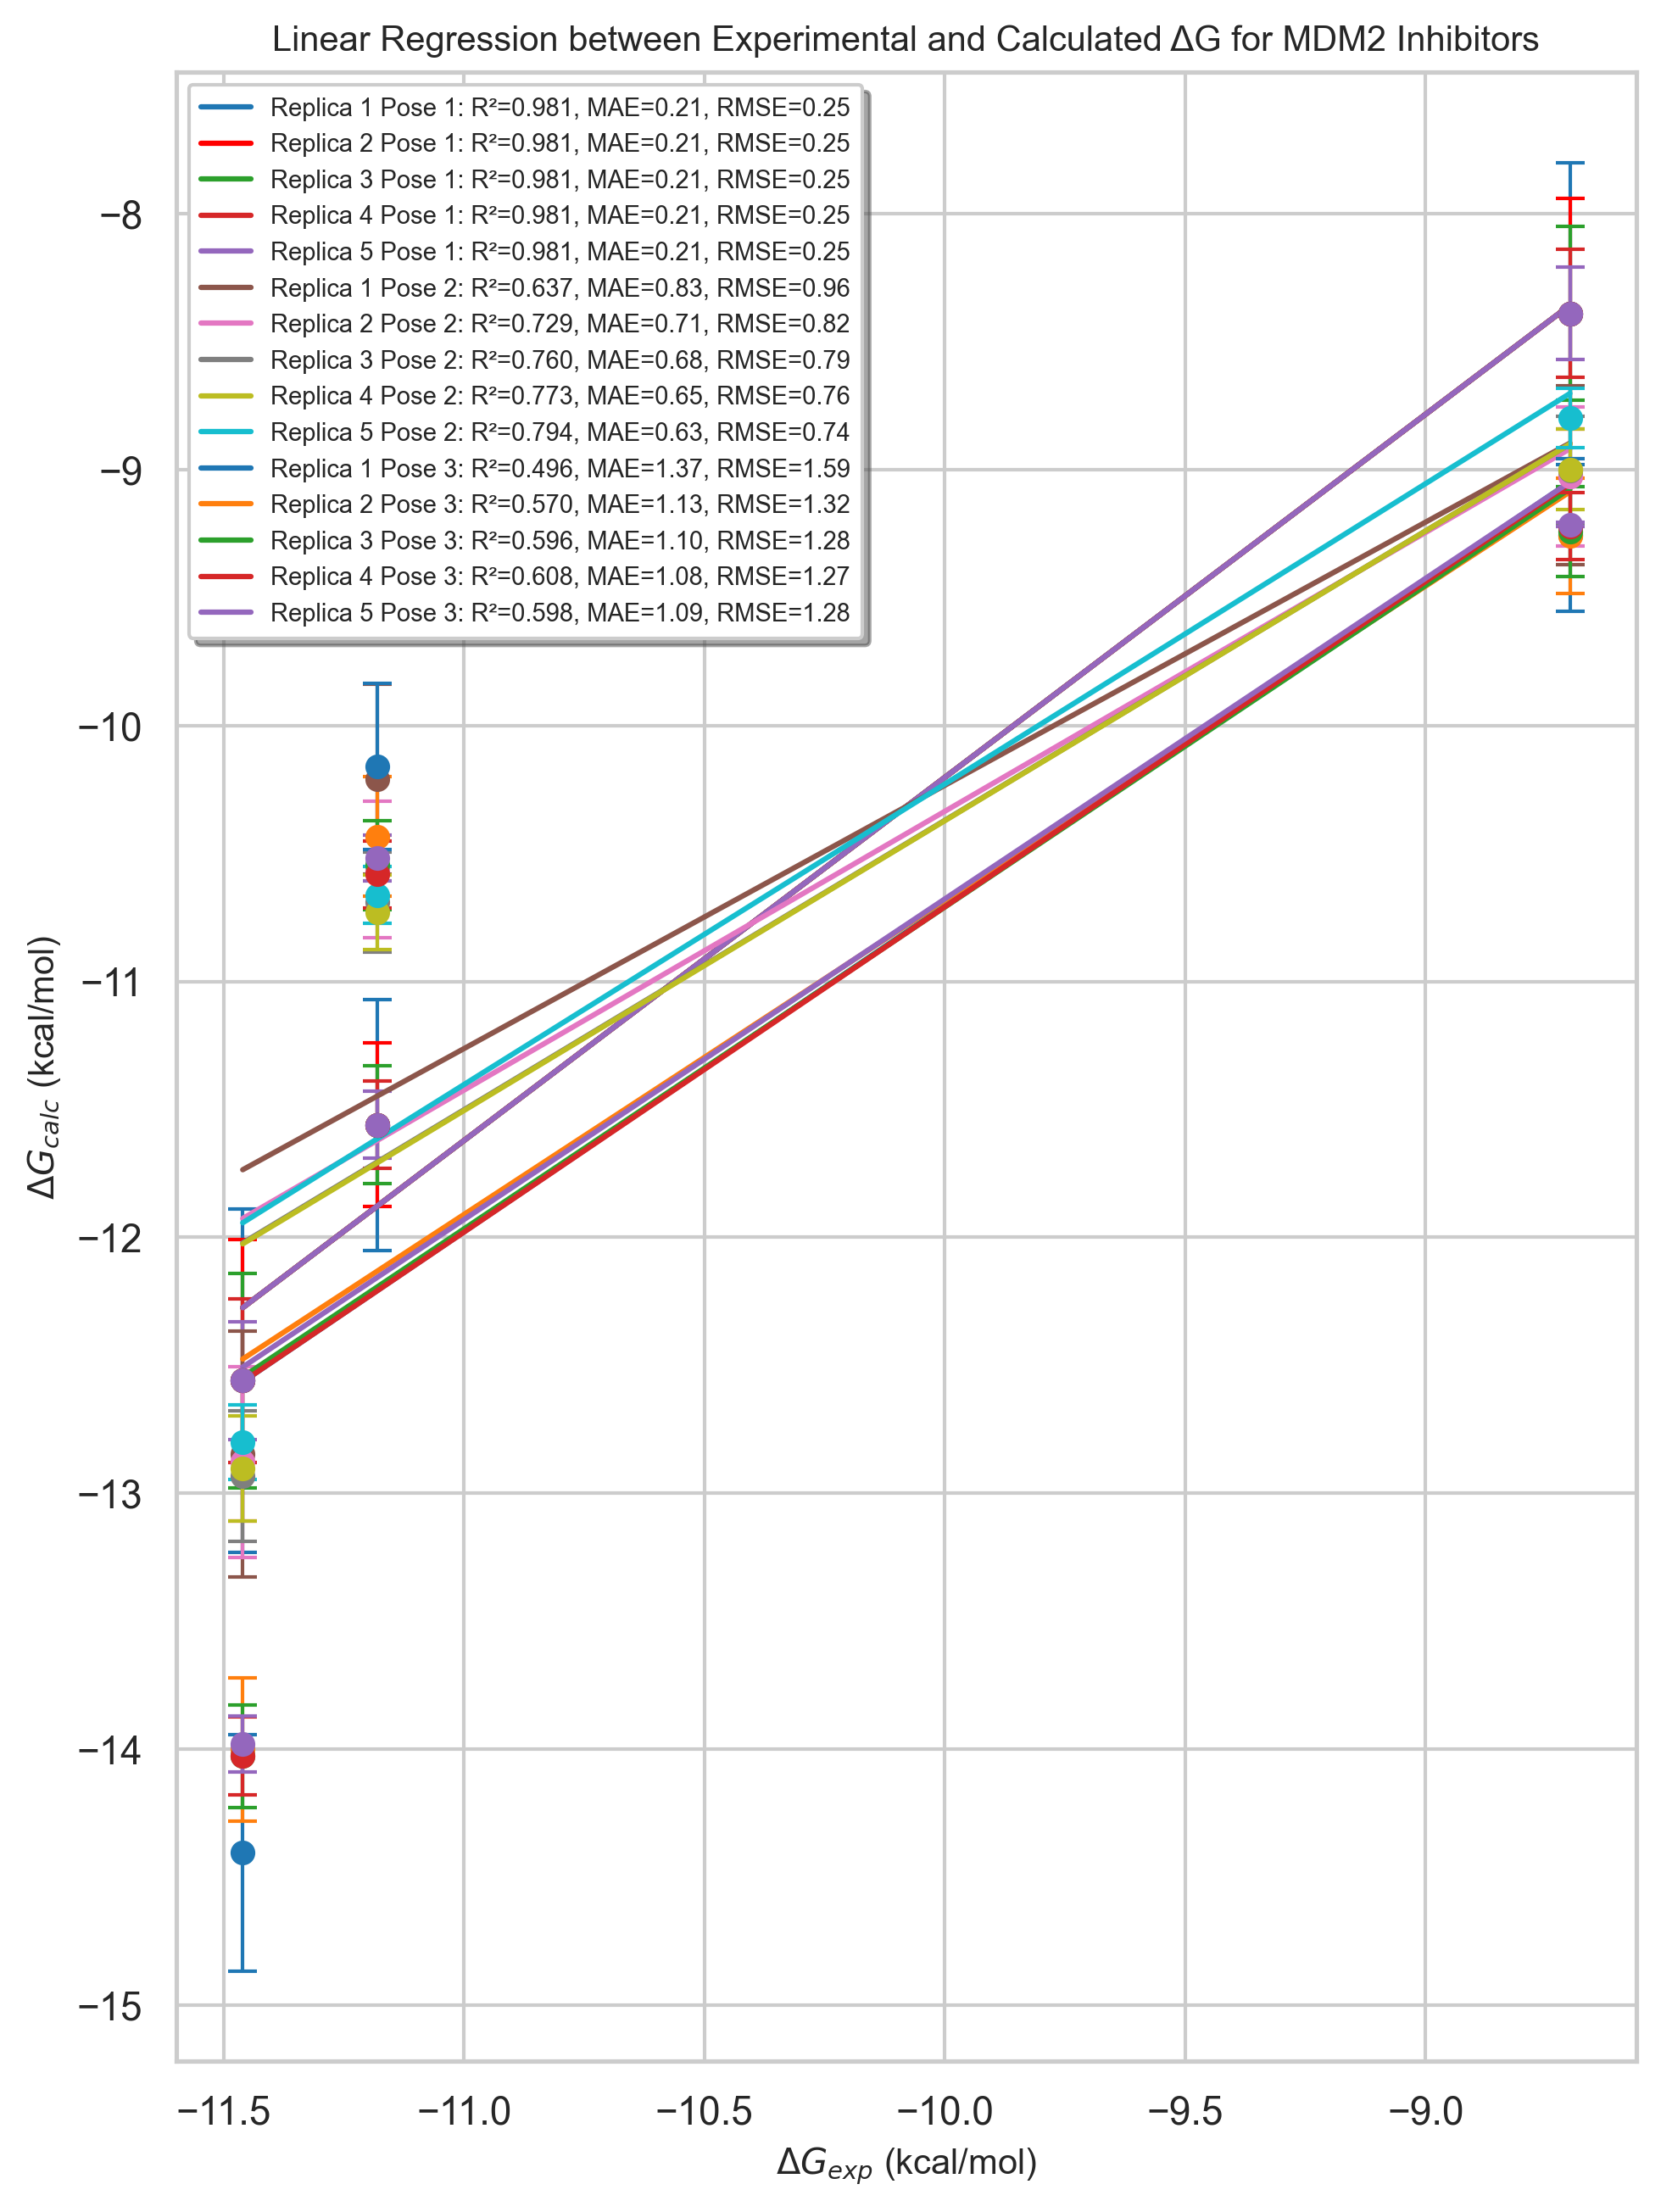

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

sns.set(style="whitegrid")

# List of tuples: (filename, legend label)
replica_files = [
    ("1P1R.xlsx", "Replica 1 Pose 1"),
    ("1P2R.xlsx", "Replica 2 Pose 1"),
    ("1P3R.xlsx", "Replica 3 Pose 1"),
    ("1P4R.xlsx", "Replica 4 Pose 1"),
    ("1P5R.xlsx", "Replica 5 Pose 1"),
    ("2P1R.xlsx", "Replica 1 Pose 2"),
    ("2P2R.xlsx", "Replica 2 Pose 2"),
    ("2P3R.xlsx", "Replica 3 Pose 2"),
    ("2P4R.xlsx", "Replica 4 Pose 2"),
    ("2P5R.xlsx", "Replica 5 Pose 2"),
    ("3P1R.xlsx", "Replica 1 Pose 3"),
    ("3P2R.xlsx", "Replica 2 Pose 3"),
    ("3P3R.xlsx", "Replica 3 Pose 3"),
    ("3P4R.xlsx", "Replica 4 Pose 3"),
    ("3P5R.xlsx", "Replica 5 Pose 3"),
]

# Experimental ΔG values (adjust as needed)
experimental_dg = np.array([-8.7, -11.18, -11.46])

# Set figure size (convert mm to inches) and DPI
plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

# Get default color palette from matplotlib
colors = plt.cm.tab10.colors

handles = []
labels = []

for i, (filename, legend_label) in enumerate(replica_files):
    # Read data from Excel file
    df = pd.read_excel(filename)
    calculated_dg = df['DG_calc'].values
    std_dev = df['std_dev'].values

    # Prepare linear regression model
    model = LinearRegression()
    X = experimental_dg.reshape(-1, 1)  # Reshape for sklearn
    y = calculated_dg
    model.fit(X, y)
    y_pred = model.predict(X)

    # Compute regression metrics
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred, squared=False)

    # Assign red color only to the specific file '1P2R.xlsx'
    if filename == "1P2R.xlsx":
        color = 'red'
    else:
        color = colors[i % len(colors)]

    # Plot points with error bars
    plt.errorbar(experimental_dg, calculated_dg, yerr=std_dev, fmt='o', color=color,
                 ecolor=color, elinewidth=1, capsize=4, linestyle='none')

    # Plot regression line
    line_handle, = plt.plot(experimental_dg, y_pred, color=color, linewidth=1.5)

    # Create legend label with regression metrics
    label_text = (f"{legend_label}: "
                  f"R²={r2:.3f}, "
                  f"MAE={mae:.2f}, "
                  f"RMSE={rmse:.2f}")

    handles.append(line_handle)
    labels.append(label_text)

# Set axis labels and plot title
plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Linear Regression between Experimental and Calculated ΔG for MDM2 Inhibitors', fontsize=10)

# Add legend with custom handles and labels
plt.legend(handles, labels, loc='upper left', fontsize=7, frameon=True,
           fancybox=True, shadow=True, borderpad=0.5)

plt.tight_layout()

# Save the figure
plt.savefig('DG_regression_with_metrics_in_legend.png', dpi=300)

plt.show()


In [4]:
import pandas as pd
from statsmodels.formula.api import mixedlm

# Carga de datos
df = pd.read_csv("Datos-RP-LIE.csv")

# Ajustar LMM: DG_calc ~ DG_exp con efecto aleatorio por ligando
modelo = mixedlm("DGcalculado ~ DGexperimental", df, groups=df["Ligando"])
resultado = modelo.fit()

# Resumen del modelo
print(resultado.summary())

# Guardar predicciones
df["DG_predicho"] = resultado.predict(df)


KeyError: 'Ligando'

In [2]:
pip install statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 12.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 7.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd

# Cargar el archivo CSV (si usaste Excel, primero guarda como CSV)
df = pd.read_csv("Datos-RP-LIE.csv", delimiter=';')

# Reemplazar comas decimales por puntos y convertir a float
df['DGcalculado'] = df['DGcalculado'].str.replace(',', '.').astype(float)
df['DG experimental'] = df['DG experimental'].str.replace(',', '.').astype(float)

# Verifica que las columnas estén correctamente leídas
print(df.columns)


Index(['Ligando', 'Replica', 'Pose', 'DGcalculado', 'DG experimental'], dtype='object')
